In [ ]:
#This is the updated script for generating frequency data from 4x Lionheart images 
#Current as of 1/19/2026

In [30]:
import numpy as np
import tifffile
from matplotlib import pyplot as plt
from cellpose import models
import torch
from scipy.signal import find_peaks
from skimage.measure import label, regionprops, regionprops_table
import math
from joblib import Parallel, delayed

#utility functions (use in other code segments as well)


#######################################################################################################################################################
#function to extract timeseries data from image stack. This one takes a separate segmentation image (use max z projection image)
#inputs:
    #stack: a 3D numpy array of the timeseries image
    #seg_img: an image to base segmentation off of. It can be a single slice of the stack, or it could be a max z projection image
    #diam: diameter of the cell the segmentation algorithm expects
#outputs:
    #data: an n-by-t 2D numpy array, containing avg calcium signal intensity for each n cell for t timepoints
    #mask: an x-by-y 2D numpy array with the same size as the seg_img input. Each value is either 0 for no cell, or [1...n] for each cell ID
    #morph: an n-by-1 1D numpy array containing the circularity value for each cell
    #size: an n-by-1 1D numpy array containing the size of the cell in pixels

def extract_data_wloc(stack, seg_img, diam=15):

    #segmenting the image to generate a mask of each cell
    img = seg_img
    model = models.Cellpose(gpu=True, model_type = 'cyto2', device=torch.device('cuda'))
    mask, flows, styles, diam = model.eval(img, diameter=diam, flow_threshold=0.2, channels=[0,0])

    #morphological characteristics
    regions = regionprops(mask)
    morph = np.zeros(mask.max()-1)
    size = np.zeros(mask.max()-1)

    for i in range(len(regions)-1):
        morph[i] = regions[i+1].axis_major_length/regions[i+1].axis_minor_length
        size[i] = mask[mask==i+1].shape[0]

    #calcium data extraction using multiprocessing. The n_jobs should be set to less than 60 for compatibility issues
    t_len = stack.shape[0]
    numcell = mask.max()-1

    def process(i, stack, mask):
        tdata=np.zeros(t_len)
        for t in range(t_len):
            a,b = np.where(mask==i+1)
            val=0
            img = stack[t,:,:]
            for j in range(a.shape[0]):
                val = val + img[a[j], b[j]]
            tdata[t] = val/a.shape[0]
        return tdata

    results = Parallel(n_jobs=59)(delayed(process)(i, stack, mask) for i in range(numcell))
    data = np.stack(results, axis=0)

    return data, mask, morph, size
#######################################################################################################################################################
#function to apply a polynomial correction to the timeseries data for each cell to correct for autofluorescence drift
#inputs:
    #data: an n-by-t 2D numpy array, containing avg calcium signal intensity for each n cell for t timepoints
    #n_poly: the order of the polynomial to fit the function to. Should be somewhere between 4-8
#outputs:
    #result: an n-by-t 2D numpy array, containing the input data with correction applied
def poly_corr(data, n_poly):
    result = np.zeros(data.shape)
    for cell in range(data.shape[0]):
        y = np.linspace(0,data.shape[1]-1,data.shape[1])
        model = np.poly1d(np.polyfit(y,data[cell,:],n_poly))
        poly = model(y)
        result[cell,:] = np.subtract(data[cell,:], poly)
    return result
#######################################################################################################################################################
#function to get timepoint on where the wave starts
#inputs:
    #x: an n-by-t 2D numpy array, containing avg calcium signal intensity for each n cell for t timepoints
    #thres: int value for the calcium intensity threshold where it will be considered the beginning of a "wave"
    #mask: an optional parameter, an x-by-y 2D numpy array with the same size as the img input. Each value is either 0 for no cell, or [1...n] for each cell ID
#outputs:
    #wave_begin: an n-by-1 1D numpy array with the timepoint at which the wave starts for each cell. It contains -1 for all cells that never reach the threshold value
def get_wave_start(x, thres, mask=None):

    wave_begin = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        try:
            wave_begin[i] = np.where(x[i,:]>thres)[0][0]
        except:
            wave_begin[i] = -1

    if mask is not None:
        new_mask = np.zeros(mask.shape)
        for i in range(mask.max()-1):
            new_mask = np.where(mask==i+1, wave_begin[i], new_mask)
        return wave_begin, new_mask
    else:
        return wave_begin
#######################################################################################################################################################
#function to select spiking cells
#inputs:
    #data: an n-by-t 2D numpy array, containing avg calcium signal intensity for each n cell for t timepoints
    #prom: int value for the prominence threshold for the spike
    #pkct_min: an optional parameter, min number of peaks to consider the cell as spiking
    #pkct_max: an optional parameter, max number of peaks to consider the cell as spiking
#outputs:
    #peak_data: an n-by-t 2D numpy array. It is same as the 'data' input except data for cells considered not spiking have been removed and replaced with NaN
    #peak_locations: a list of length n. Contains [np.nan] for cells not spiking. Contains the numpy array of indices where spiking happened for cells that had
    #                spiking events
    #peak_binary: a list of length n. Contains 1 for cells that are spiking, 0 for cells that are not spiking
    #peak_height: a list of length n. Contains 0 for cells not spiking. Contains the numpy array of prominences where spiking happened for cells that had
    #             spiking events
def select_spiking(data, prom, pkct_min=3, pkct_max=100):
    def count_peaks(x, p):
        peaks, properties = find_peaks(x, prominence = p)
        return peaks, properties

    peak_data=[]
    peak_locations = []

    peak_binary = []
    pk_height = []

    for i in range(data.shape[0]):
        pks, pp = count_peaks(data[i,:], prom)
        count = pks.shape[0]
        if (count > pkct_min and count < pkct_max):
            peak_data.append(data[i,:])
            peak_locations.append(pks)
            peak_binary.append(1)
            pk_height.append(pp['prominences'].mean())
        else:
            empty_ex = np.empty(data[i,:].shape)
            empty_ex[:]=np.nan
            peak_data.append(empty_ex)
            peak_locations.append(np.array([np.nan]))
            peak_binary.append(0)
            pk_height.append(0)

    return np.asarray(peak_data), peak_locations, peak_binary, pk_height
#######################################################################################################################################################
#function to generate spiking frequency of the spiking cells. It takes the average number of timepoints between each spiking event for the cells
#inputs:
    #j: an n-by-t 2D numpy array. It contains average calcium intensity for cells except data for cells considered not spiking have been
    #   removed and replaced with NaN. Use output from the select_spiking() function
    #threshold: integer value for the maximum interval between spiking events. Any interval higher than this is ignored
#outputs:
    #freq: an n-by-1 1D numpy array containing the average interval length between each spike for each cell. It contains np.nan for cells that do not have spiking
def get_cell_freq(j, threshold):

    freq = np.zeros(len(j))
    for i in range(len(j)):
        if np.any(j[i] == np.nan):
            freq[i] = 0
        else:
            dif=0
            ind=0
            for pk in range(j[i].shape[0]-1):
                if (j[i][pk+1] - j[i][pk]) <= threshold:
                    dif = dif + j[i][pk+1] - j[i][pk]
                    ind=ind+1
            try:
                freq[i]= dif/ind
            except:
                freq[i]=0
    freq[freq==0] = np.nan
    freq[freq > threshold] = np.nan
    return freq


In [25]:
#image file name and the timepoints to take here. 
imgset = tifffile.imread('control.tif')[0:200,:,:]

In [26]:
data, mask, morph, size= extract_data_wloc(imgset, imgset[0,:,:])
data = poly_corr(data, 6)
peak_data, peak_locations, peak_binary, pk_height = select_spiking(data, 80) 
pk_flt = []
for i in range(len(peak_locations)):
    if peak_binary[i]==1:
        pk_flt.append(peak_locations[i])

print("Fraction of cells deemed spiking")
print(len(pk_flt)/len(peak_locations))
x = get_cell_freq(pk_flt, 40)

0.9913860610806577


The average frequency is
12.758550354828536


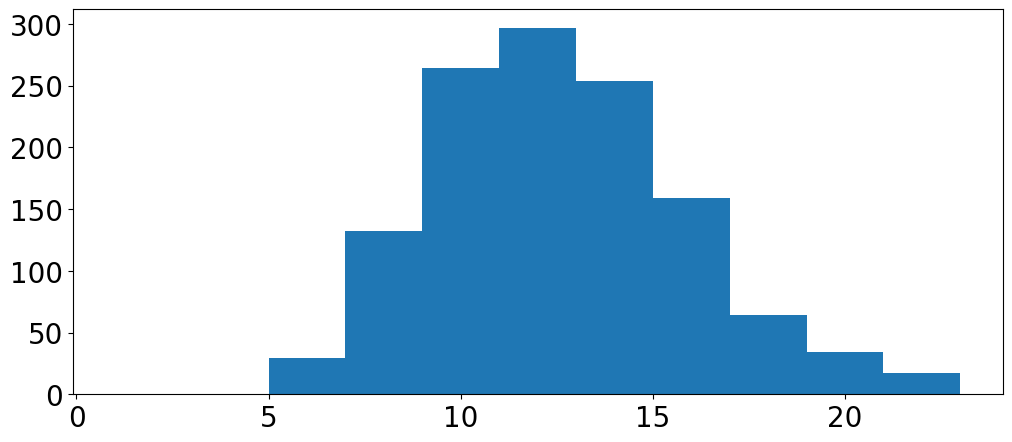

In [31]:
plt.figure(figsize = (12,5));
plt.hist(1/(x*5)*1000, bins=np.arange(1,25,2));
plt.xticks(fontsize=20);
plt.yticks(fontsize=20);
print("The average frequency is")
print(np.nanmean(1/(x*5)*1000))

In [149]:
#output the peak info as a csv file 
np.savetxt('n4.csv', np.append(np.asarray([peak_binary]).T, data, axis=1), delimiter=',')
file = open('n4_peaks.txt', 'w')

for peak in peak_locations:
    file.write(' '.join([str(i) for i in peak]) + '\n')
file.close()

In [ ]:
#snippet to remove nan data (nonspiking cells)
peak_data = peak_data[~np.isnan(peak_data).any(axis=1)]
y=[i for i in peak_locations if i[0]!='nan']

#get the peak timepoint locations for each cell 
pk_flt = []
for i in range(len(peak_locations)):
    if peak_binary[i]==1:
        pk_flt.append(peak_locations[i])